# 01 — Análise Exploratória do FAERS 2023

**Objetivo:** entender estrutura, volumes, qualidade dos dados e padrões básicos antes de detectar sinais.

## Roteiro
1. Visão geral das 7 tabelas
2. Deduplicação de casos (DEMO)
3. Demografia (idade, sexo, país)
4. Top medicamentos e top reações reportados
5. Distribuição de desfechos (sério vs. não-sério, mortes)
6. Decisões para o pipeline

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import (
    dedupe_demo, normalize_age, normalize_drug_table, aggregate_outcomes
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

PROCESSED = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Visão geral

In [2]:
tables = {}
for tbl in ["demo", "drug", "reac", "outc", "indi", "rpsr", "ther"]:
    tables[tbl] = pd.read_parquet(PROCESSED / f"{tbl}_2023.parquet")

summary = pd.DataFrame([
    {"tabela": k, "linhas": len(v), "colunas": len(v.columns)}
    for k, v in tables.items()
])
summary

,tabela,linhas,colunas
0,demo,1673637,26
1,drug,7473722,21
2,reac,5843817,5
3,outc,1247923,4
4,indi,4521741,5
5,rpsr,52497,4
6,ther,2587650,8


In [3]:
# Distribuição por trimestre
for tbl in ["demo", "drug", "reac"]:
    print(f"{tbl.upper():6s} por trimestre:", tables[tbl]["quarter"].value_counts().sort_index().to_dict())

DEMO   por trimestre: {1: 432144, 2: 418592, 3: 407522, 4: 415379}
DRUG   por trimestre: {1: 1899503, 2: 1885096, 3: 1768391, 4: 1920732}
REAC   por trimestre: {1: 1491473, 2: 1478973, 3: 1373338, 4: 1500033}


## 2. Deduplicação

O mesmo caso (`caseid`) pode aparecer em múltiplos trimestres com versões diferentes (`caseversion`). Mantemos só a versão mais recente.

In [4]:
demo = tables["demo"]
print(f"Antes dedup: {len(demo):,} linhas, {demo['caseid'].nunique():,} caseids únicos")

demo_dedup = dedupe_demo(demo)
print(f"Após dedup:  {len(demo_dedup):,} linhas (1 por caso)")
print(f"Redução: {(1 - len(demo_dedup) / len(demo)) * 100:.1f}% das linhas")

Antes dedup: 1,673,637 linhas, 1,544,991 caseids únicos


Após dedup:  1,544,991 linhas (1 por caso)
Redução: 7.7% das linhas


## 3. Demografia

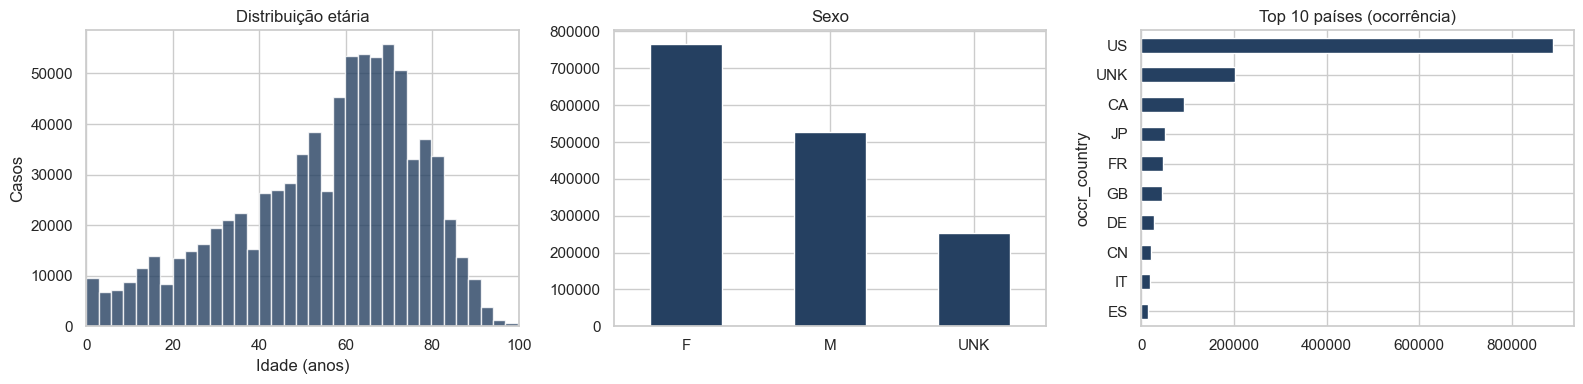


Idade média: 55.4 anos | mediana: 60.0
% com idade válida: 54.1%


In [5]:
demo_norm = normalize_age(demo_dedup)
demo_norm["sex"] = demo_norm["sex"].fillna("UNK")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Idade
axes[0].hist(demo_norm["age_years"].dropna(), bins=40, color="#254061", alpha=0.8)
axes[0].set_title("Distribuição etária")
axes[0].set_xlabel("Idade (anos)")
axes[0].set_ylabel("Casos")
axes[0].set_xlim(0, 100)

# Sexo
demo_norm["sex"].value_counts().plot(kind="bar", ax=axes[1], color="#254061")
axes[1].set_title("Sexo")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

# País
if "occr_country" in demo_norm.columns:
    demo_norm["occr_country"].fillna("UNK").value_counts().head(10).plot(
        kind="barh", ax=axes[2], color="#254061"
    )
    axes[2].set_title("Top 10 países (ocorrência)")
    axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / "01_demographics.png", bbox_inches="tight")
plt.show()

print(f"\nIdade média: {demo_norm['age_years'].mean():.1f} anos | mediana: {demo_norm['age_years'].median():.1f}")
print(f"% com idade válida: {demo_norm['age_years'].notna().mean()*100:.1f}%")

## 4. Top medicamentos e top reações

In [6]:
drug = tables["drug"]
print(f"Total de linhas drug: {len(drug):,}")
print(f"\nDistribuição role_cod (papel do medicamento):")
drug["role_cod"].value_counts(dropna=False)

Total de linhas drug: 7,473,722

Distribuição role_cod (papel do medicamento):


role_cod
SS      2948230
C       2800454
PS      1673575
I         51461
None          2
Name: count, dtype: int64

Após normalização: 7,470,835 linhas (com drug_norm não vazio)


Drogas únicas normalizadas: 57,415


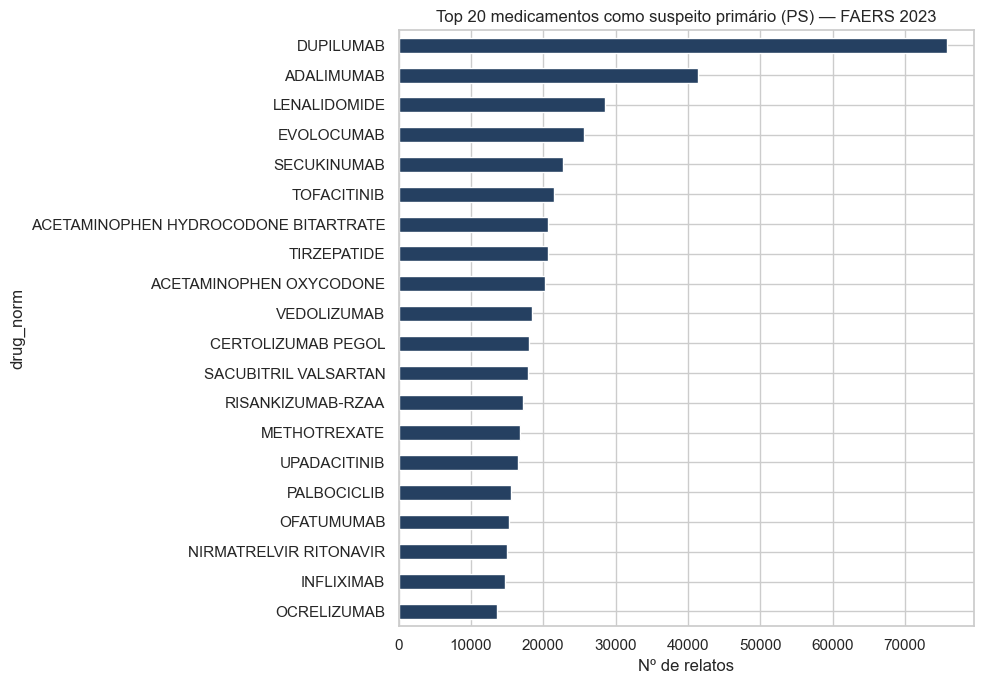

In [7]:
# Normalizar nomes
drug_norm = normalize_drug_table(drug)
print(f"Após normalização: {len(drug_norm):,} linhas (com drug_norm não vazio)")
print(f"Drogas únicas normalizadas: {drug_norm['drug_norm'].nunique():,}")

# Filtrar só PS (primary suspect) para top drugs
ps = drug_norm[drug_norm["role_cod"].fillna("").str.upper() == "PS"]
top_drugs = ps["drug_norm"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_drugs.iloc[::-1].plot(kind="barh", ax=ax, color="#254061")
ax.set_title("Top 20 medicamentos como suspeito primário (PS) — FAERS 2023")
ax.set_xlabel("Nº de relatos")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_top_drugs.png", bbox_inches="tight")
plt.show()

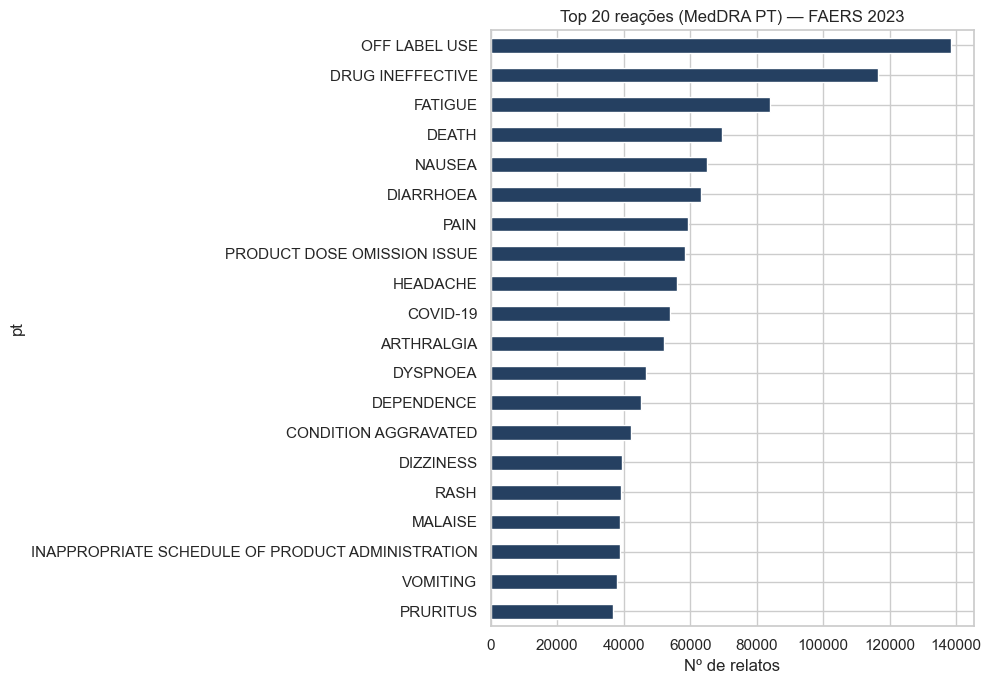

In [8]:
reac = tables["reac"]
reac["pt"] = reac["pt"].fillna("").str.upper().str.strip()
top_reactions = reac[reac["pt"] != ""]["pt"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_reactions.iloc[::-1].plot(kind="barh", ax=ax, color="#254061")
ax.set_title("Top 20 reações (MedDRA PT) — FAERS 2023")
ax.set_xlabel("Nº de relatos")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_top_reactions.png", bbox_inches="tight")
plt.show()

## 5. Desfechos

In [9]:
outc = tables["outc"]
outc_agg = aggregate_outcomes(outc)

print(f"Casos com desfecho reportado: {len(outc_agg):,}")
print(f"\nDistribuição dos códigos OUTC:")
outc["outc_cod"].value_counts()

Casos com desfecho reportado: 961,967

Distribuição dos códigos OUTC:


outc_cod
OT    704182
HO    335986
DE    131705
LT     47265
DS     21863
CA      3578
RI      3344
Name: count, dtype: int64

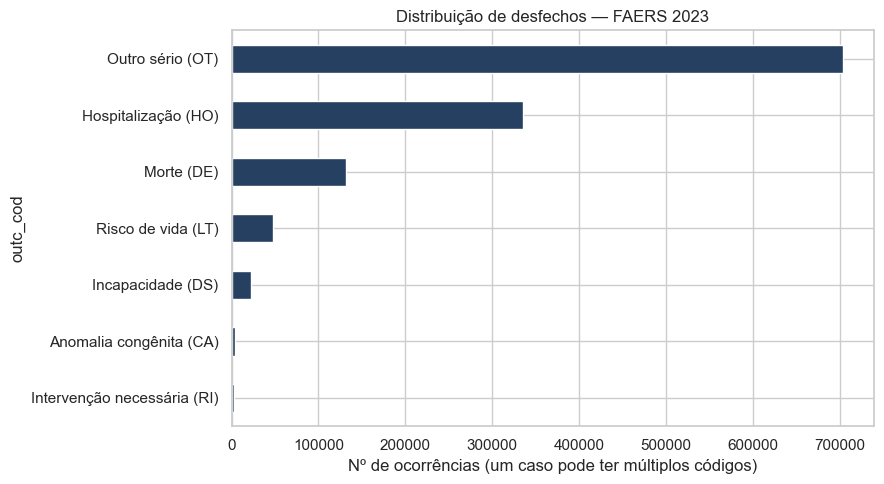


Taxa de casos sérios: 49.3%
Taxa de mortes: 13.7%
Taxa de hospitalizações: 34.9%


In [10]:
# Severidade por código
OUTC_LABELS = {
    "DE": "Morte (DE)",
    "LT": "Risco de vida (LT)",
    "HO": "Hospitalização (HO)",
    "DS": "Incapacidade (DS)",
    "CA": "Anomalia congênita (CA)",
    "RI": "Intervenção necessária (RI)",
    "OT": "Outro sério (OT)",
}
counts = outc["outc_cod"].value_counts().rename(index=OUTC_LABELS)

fig, ax = plt.subplots(figsize=(9, 5))
counts.plot(kind="barh", ax=ax, color="#254061")
ax.set_title("Distribuição de desfechos — FAERS 2023")
ax.invert_yaxis()
ax.set_xlabel("Nº de ocorrências (um caso pode ter múltiplos códigos)")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_outcomes.png", bbox_inches="tight")
plt.show()

print(f"\nTaxa de casos sérios: {outc_agg['serious'].mean()*100:.1f}%")
print(f"Taxa de mortes: {outc_agg['death'].mean()*100:.1f}%")
print(f"Taxa de hospitalizações: {outc_agg['hospitalization'].mean()*100:.1f}%")

## 6. Decisões para o pipeline

Com base nesta exploração, o pipeline (notebooks 02–05) vai:

### Pré-processamento (notebook 02)
- **Deduplicar** DEMO por `caseid` mantendo última versão (ver redução real acima).
- **Normalizar idade** para anos numéricos.
- **Normalizar nomes de medicamentos**: priorizar `prod_ai` (princípio ativo); fallback `drugname`.
- **Filtrar PS** (primary suspect) para análise de sinais — reduz ruído.
- **Agregar OUTC** em flags binários: `serious`, `death`, `hospitalization`.

### Detecção de sinais (notebook 03)
- Montar matriz droga × reação com pares (caso × droga × reação) deduplicados.
- Filtrar pares com `a >= 3` (padrão FDA).
- Calcular **PRR + ROR + IC** com intervalos de confiança 95%.
- Flag de sinal positivo: PRR ≥ 2 ∧ χ² ≥ 4 ∧ IC025 > 0.

### Modelo de severidade (notebook 04)
- Target: `serious` (binário) por caso.
- Features: idade, sexo, droga PS, n° drogas concomitantes, indicação, reportante.
- XGBoost + Optuna + SHAP, similar ao projeto 1 (mas em domínio diferente).

### Análise de rede (notebook 05)
- Nós: drogas (PS + concomitantes).
- Arestas: co-reportadas no mesmo caso.
- Métricas: centralidade, comunidades (Louvain).
- Visualização interativa com PyVis.